In [2]:
import json
from typing import TypedDict,List,Optional,Dict,Any
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END

In [3]:
class HabitState(TypedDict,total=False):
    uid: Optional[str]
    saved_dishes: List[Dict]
    recommendations:List[Dict]
    analytics:Dict
    habit_summary:Optional[str]
    error_message:Optional[str]

class HabitSummary(BaseModel):
    headline:str
    insights:str
    weekly_trends:Dict[str,float]
    most_liked_tags:List[str]
    most_disliked_tags: List[str]
    recommended_cuisines: List[str]
    total_interactions: int

In [4]:
def safe_load_json(text: str) -> dict:
    try:
        return json.loads(text)
    except Exception:
        return {}

In [5]:
def fetch_dish_history(state:HabitState)->HabitState:
    """Fetches user's dish Interaction(like/dislikes)"""

    print("[NODE] fetch_dish_history")
    try:
        uid=state.get(uid)
        if not uid:
            raise ValueError("UID missing")
        
        docs=list(db.collection("dish_states").document(uid).collection("history").stream())
        if not docs:
            return {**state,"saved_dishes":[]}
        
        saved_dishes=[]
        for doc in docs:
            data=doc.to_dict()
            saved_dishes.append(data)
        return {**state,"saved_dishes":saved_dishes}
    except Exception as e:
        return {**state,"error_message":f"failed to fetch dishes:{e}"}
    

In [6]:
def fetch_recommends_history(state:HabitState)->HabitState:
    """
     Fetches user's recommendations interactions
    """
    print("[NODE] fetch_recommendation_history")
    try:
        uid=state.get(uid)
        if not uid:
            raise ValueError("UID Missing")
        
        doc=db.collection("recommendation_states").document(uid).get()
        recommendations=[]
        if doc.exists:
            rec_state=doc.to_dict()
            if rec_state.get("current_recommendation"):
                rec=rec_state["current_recommendation"]
                recommendations.append(rec)
        return {**state,"recommendations":recommendations}
    except Exception as e:
        return {**state,"error_message":f"Failed to get recommendations: {e}"}

In [7]:
def fetch_analytics(state:HabitState)->HabitState:
    """
    Fetches Analytics Summary if any
    """
    print("[NODE] fetch_analytics")
    try:
        uid=state.get(uid)
        if not uid:
            raise ValueError("UID missing")
        
        doc=db.collection("userAnalytics").document(uid).get()
        if doc.exists:
            analytics=doc.to_dict()
            return {**state,"analytics":analytics}
        return {**state,"analytics":analytics}
    except Exception as e:
        return {**state,"error_message":f"Failed to fetch user Analytics:{e}"}
    
def generate_habit_summary(state:HabitState)->HabitState:
    """
    Analyzes User patterns and generate human Readable habit summary
    """
    print("[NODE] generate_habit_summary")
    if state.get("error_message"):
        return state
    
    saved_dishes=state.get("saved_dishes",[])
    recommendations=state.get("recommendations",[])
    analytics=state.get({"analytics":{}})

    if not saved_dishes and not recommendations:
        return {**state,"habit_summary":"You Haven't Interacted with my System Yet. Whyyy?"}
    
    liked_tags={}
    disliked_tags={}
    cuisines=set()
    total_interactions=len(saved_dishes) +len(recommendations)
    calories_list=[]

    for dish in saved_dishes:
        tags=dish.get("current_dish",{}).get("tags",[])
        action=dish.get("preference_action")
        if action == "like":
            for t in tags:
                liked_tags[t]=liked_tags.get(t,0)+1
        elif action == "dislike":
            for t in tags:
                disliked_tags[t]=disliked_tags.get(t,0) + 1
        
        metadata=dish.get("current_dish",{}).get("metadata",{})
        cal=metadata.get("calories")
        if cal:
            cal_value=float(re.search(r"[\d\.]",str(cal)).group(0))
            calories_list.append(cal_value)
        cuisine=metadata.get("cuisines")
        if cuisine:
            cuisines.add(cuisine)
        
    avg_calories=round(sum(calories_list)/len(calories_list), 2) if calories_list else 0

    summary_obj = HabitSummary(
        headline="Your Eating Habits Overview",
        insights=f"Avg calories per meal: {avg_calories} kcal. Total interactions: {total_interactions}.",
        weekly_trends={"avg_calories": avg_calories},
        most_liked_tags=sorted(liked_tags, key=liked_tags.get, reverse=True)[:5],
        most_disliked_tags=sorted(disliked_tags, key=disliked_tags.get, reverse=True)[:5],
        recommended_cuisines=list(cuisines),
        total_interactions=total_interactions
        )
    
    summary=summary_obj.json()

    prompt=f"""
You are a habit Tracker Expert AI Agent.

The following is structured data about a user's food habits:

{summary}

Generate a friendly, motivating natural-language summary describing:
- User's average calorie intake
- What kinds of tags/flavors they prefer or avoid
- The cuisines they seem to gravitate towards
- Overall eating patterns
- A short helpful suggestion on how they can improve nutrition

Write the summary in 6-8 sentences.
"""
    llm_response=llm.invoke(prompt)

    return {**state,"habit_summary":llm_response}

In [8]:
graph=StateGraph(HabitState)

graph.add_node("fetch_dish_history",fetch_dish_history)
graph.add_node("fetch_dish_recommendations",fetch_recommends_history)
graph.add_node("fetch_analytics",fetch_analytics)
graph.add_node("generate_habit_summary",generate_habit_summary)

graph.add_edge(START,"fetch_dish_history")
graph.add_edge("fetch_dish_history","fetch_dish_recommendations")
graph.add_edge("fetch_dish_recommendations","fetch_analytics")
graph.add_edge("fetch_analytics","generate_habit_summary")
graph.add_edge("generate_habit_summary",END)



habit_agent=graph.compile()

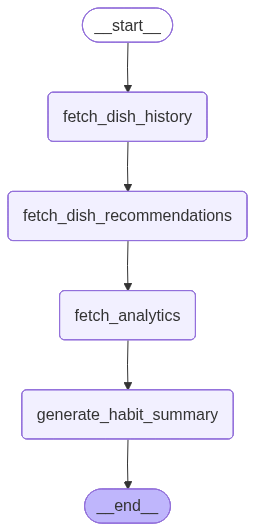

In [9]:
from IPython.display import display,Image
display(Image(habit_agent.get_graph().draw_mermaid_png()))